# CardioIA · Ir Além 2: diagnóstico visual de ECG com rede neural MLP

Objetivo: classificar batimentos cardíacos como **normal** ou **anormal** a partir da **imagem** do traçado de eletrocardiograma, com uma rede neural do tipo **MLP** (Perceptron Multicamadas) construída em Keras.

| Etapa | O que acontece |
|---|---|
| 1. Dados | PTB Diagnostic ECG Database, na versão pré-processada do Kaggle (`shayanfazeli/heartbeat`) |
| 2. Imagens | cada batimento é desenhado como traçado sobre papel de ECG |
| 3. Pré-processamento | tons de cinza → redimensionamento para 32 × 64 → normalização → vetor de 2.048 pixels |
| 4. MLP | 2.048 → 256 → 128 → 1 neurônio, com *dropout* |
| 5. Avaliação | acurácia, sensibilidade, especificidade, AUC e matriz de confusão |
| 6. Análise | comparação com a MLP sobre o sinal bruto, teste de deslocamento, erros e limitações |

**Como executar:** no Google Colab, basta rodar as células (TensorFlow e `kagglehub` já vêm instalados). Localmente: `pip install tensorflow kagglehub scikit-learn pandas matplotlib`. O download do dataset (cerca de 100 MB) é automático e não exige conta no Kaggle.

> Material educacional. Não é dispositivo médico e não deve apoiar decisão sobre paciente real.

In [1]:
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'                     # silencia os logs internos do TensorFlow
warnings.filterwarnings('ignore', message='IProgress not found')  # barra de progresso do download fora do Colab

from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split

tf.keras.utils.set_random_seed(42)              # mesmos pesos iniciais e mesma ordem de lotes a cada execução
tf.config.experimental.enable_op_determinism()  # operações determinísticas: resultado reproduzível
print('TensorFlow', tf.__version__)

TensorFlow 2.18.0


## 1. Dados

A **PTB Diagnostic ECG Database** (PhysioNet) reúne 549 exames de 290 pessoas. Kachuee, Fazeli e Sarrafzadeh (2018) usaram a derivação II, reamostrada a 125 Hz, e recortaram cada exame em **batimentos**: cada linha do CSV é um batimento com 187 amostras (cerca de 1,5 s), amplitude normalizada entre 0 e 1 e zeros completando o final quando o batimento é mais curto. A última coluna é o rótulo:

- **0 = normal**: batimentos de controles saudáveis;
- **1 = anormal**: batimentos de pacientes com **infarto do miocárdio**.

In [2]:
pasta = Path(kagglehub.dataset_download('shayanfazeli/heartbeat'))  # baixa uma vez e reaproveita o cache
batimentos = pd.concat([pd.read_csv(pasta / 'ptbdb_normal.csv', header=None),
                        pd.read_csv(pasta / 'ptbdb_abnormal.csv', header=None)], ignore_index=True)

X_sinal = batimentos.iloc[:, :-1].to_numpy(dtype='float32')  # 187 amostras por batimento
y = batimentos.iloc[:, -1].astype(int).to_numpy()            # 0 = normal, 1 = anormal
CLASSES = ['normal', 'anormal']

print('batimentos × amostras:', X_sinal.shape)
pd.Series(y).map(dict(enumerate(CLASSES))).value_counts().rename('batimentos')

batimentos × amostras: (14552, 187)


anormal    10506
normal      4046
Name: batimentos, dtype: int64

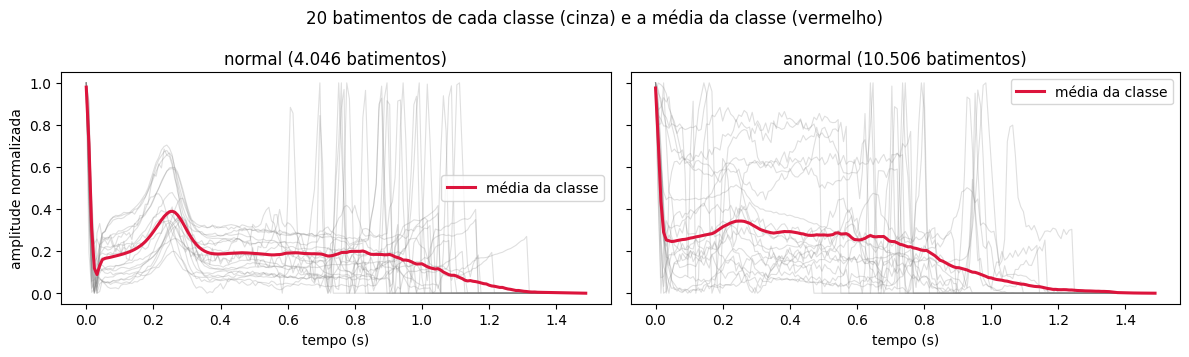

In [3]:
tempo = np.arange(X_sinal.shape[1]) / 125  # 125 amostras por segundo

fig, eixos = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for classe, eixo in enumerate(eixos):
    grupo = X_sinal[y == classe]
    for sinal in grupo[:20]:
        eixo.plot(tempo, sinal, color='gray', alpha=0.25, linewidth=0.8)
    eixo.plot(tempo, grupo.mean(axis=0), color='crimson', linewidth=2.2, label='média da classe')
    eixo.set(title=f'{CLASSES[classe]} ({len(grupo):,} batimentos)'.replace(',', '.'), xlabel='tempo (s)')
    eixo.legend()
eixos[0].set_ylabel('amplitude normalizada')
plt.suptitle('20 batimentos de cada classe (cinza) e a média da classe (vermelho)')
plt.tight_layout()
plt.show()

Cada recorte começa no pico da onda R (amplitude 1 no instante zero), passa pela onda T e, quando o coração bate mais rápido, já mostra o início do batimento seguinte; o trecho final em zero é preenchimento. Na média, o batimento normal tem a onda T bem definida, e o de infarto mostra o segmento entre o QRS e a onda T elevado e achatado.

A base é **desbalanceada**: 72% dos batimentos são anormais. Um "modelo" que respondesse sempre *anormal* já teria 72% de acurácia sem aprender nada, por isso a avaliação vai além da acurácia e o treino usa pesos por classe (seção 4).

## 2. Do sinal à imagem

O dataset entrega o batimento como uma sequência de números. Para trabalhar com **imagens**, como pede a atividade, cada batimento é desenhado do jeito que aparece num eletrocardiograma impresso: traço preto sobre papel milimetrado rosa (o mesmo padrão visual das imagens de ECG da Fase 1), em 128 × 256 pixels coloridos. É a situação de muitos hospitais brasileiros, onde o ECG existe só em papel ou em foto.

In [4]:
ALTURA, LARGURA = 128, 256  # imagem "original", colorida


def papel_ecg(altura, largura, passo=8):
    """Fundo rosa com grade fina a cada `passo` pixels e grade grossa a cada 5 passos."""
    papel = np.full((altura, largura, 3), (255, 240, 240), dtype=np.uint8)
    for p in range(0, altura, passo):
        papel[p, :] = (240, 160, 160) if p % (5 * passo) == 0 else (250, 210, 210)
    for p in range(0, largura, passo):
        papel[:, p] = (240, 160, 160) if p % (5 * passo) == 0 else (250, 210, 210)
    return papel


PAPEL = papel_ecg(ALTURA, LARGURA)


def desenhar_ecg(sinais):
    """Desenha cada batimento como traço preto (cerca de 3 px) sobre o papel. Devolve (n, 128, 256, 3) em uint8."""
    x_original, x_imagem = np.linspace(0, 1, sinais.shape[1]), np.linspace(0, 1, LARGURA)
    amostras = np.stack([np.interp(x_imagem, x_original, s) for s in sinais])           # um ponto por coluna
    linha = np.round(ALTURA * 0.05 + (1 - amostras) * (ALTURA * 0.9 - 1)).astype(int)  # amplitude → linha
    seguinte = np.concatenate([linha[:, 1:], linha[:, -1:]], axis=1)
    topo, base = np.minimum(linha, seguinte) - 1, np.maximum(linha, seguinte) + 1      # liga pontos vizinhos
    linhas = np.arange(ALTURA)[None, :, None]
    traco = (linhas >= topo[:, None, :]) & (linhas <= base[:, None, :])
    imagens = np.broadcast_to(PAPEL, (len(sinais), ALTURA, LARGURA, 3)).copy()
    imagens[traco] = (20, 20, 20)
    return imagens

## 3. Pré-processamento

As mesmas etapas que se aplicariam a um ECG fotografado ou digitalizado:

1. **tons de cinza**: 3 canais de cor viram 1 (a cor do papel não carrega informação diagnóstica);
2. **inversão**: traço claro (perto de 1) e fundo escuro (perto de 0), como no MNIST. A maior parte das entradas fica perto de zero, o que facilita o treino;
3. **redimensionamento** de 128 × 256 para 32 × 64 por média de área (suaviza o serrilhado): de 98.304 valores para 2.048;
4. **normalização** em [0, 1] e **achatamento**: a MLP recebe um vetor, não uma matriz.

In [5]:
ALTURA_MLP, LARGURA_MLP = 32, 64


def preprocessar(imagens):
    """RGB uint8 → cinza invertido → 32 × 64 → vetor de 2.048 valores em [0, 1]."""
    cinza = 1.0 - tf.image.rgb_to_grayscale(tf.cast(imagens, tf.float32) / 255.0)
    reduzida = tf.image.resize(cinza, (ALTURA_MLP, LARGURA_MLP), method='area')
    return tf.reshape(reduzida, (len(imagens), -1)).numpy()


# em lotes de 512, para não manter todas as imagens coloridas na memória ao mesmo tempo
X_img = np.concatenate([preprocessar(desenhar_ecg(X_sinal[i:i + 512])) for i in range(0, len(X_sinal), 512)])
print('entrada da MLP:', X_img.shape, '| valores entre', round(float(X_img.min()), 2), 'e', round(float(X_img.max()), 2))

entrada da MLP: (14552, 2048) | valores entre 0.04 e 0.92


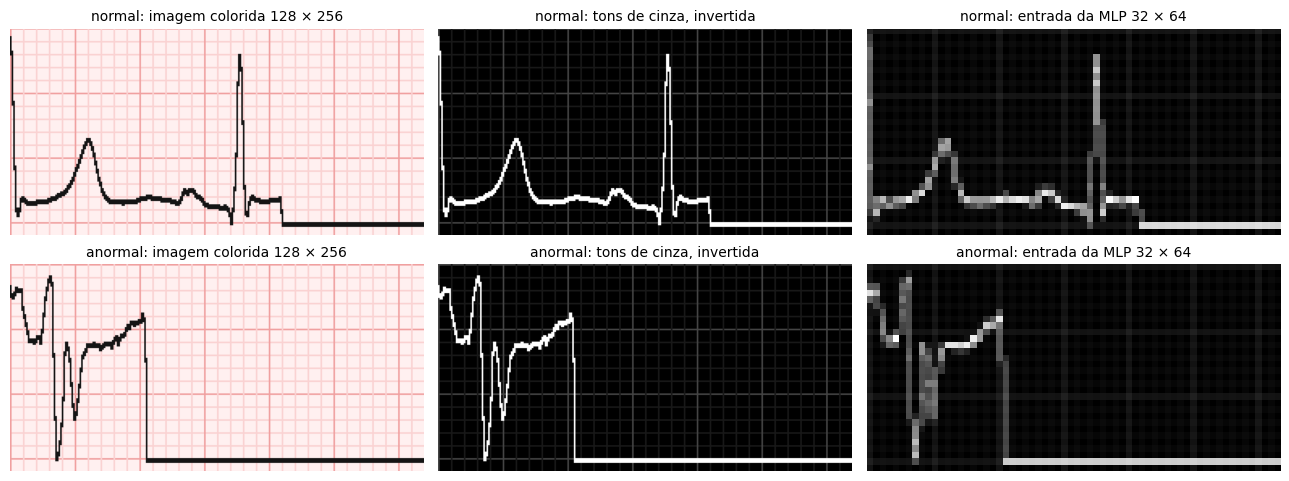

In [6]:
exemplos = [np.flatnonzero(y == 0)[0], np.flatnonzero(y == 1)[0]]
fig, eixos = plt.subplots(2, 3, figsize=(13, 5))
for eixos_linha, i in zip(eixos, exemplos):
    colorida = desenhar_ecg(X_sinal[i:i + 1])[0]
    cinza = (1.0 - tf.image.rgb_to_grayscale(colorida[None] / 255.0))[0, ..., 0].numpy()
    etapas = [(colorida, None, 'imagem colorida 128 × 256'),
              (cinza, 'gray', 'tons de cinza, invertida'),
              (X_img[i].reshape(ALTURA_MLP, LARGURA_MLP), 'gray', 'entrada da MLP 32 × 64')]
    for eixo, (imagem, cmap, titulo) in zip(eixos_linha, etapas):
        eixo.imshow(imagem, cmap=cmap)
        eixo.set_title(f'{CLASSES[y[i]]}: {titulo}', fontsize=10)
        eixo.axis('off')
plt.tight_layout()
plt.show()

## 4. Treino, validação e teste

Divisão estratificada 70% / 15% / 15%: o treino ajusta os pesos, a validação decide quando parar e o teste só é usado na avaliação final. Os mesmos índices servem para as duas representações (imagem e sinal), o que torna a comparação da seção 7 justa.

Para compensar o desbalanceamento, cada classe recebe um peso inversamente proporcional ao seu tamanho: errar um batimento normal (classe minoritária) custa mais na função de perda.

In [7]:
indices = np.arange(len(y))
i_treino, i_resto = train_test_split(indices, test_size=0.30, stratify=y, random_state=42)
i_val, i_teste = train_test_split(i_resto, test_size=0.50, stratify=y[i_resto], random_state=42)

contagem = np.bincount(y[i_treino])
pesos_classe = {classe: len(i_treino) / (2 * n) for classe, n in enumerate(contagem)}

print(f'treino {len(i_treino)} | validação {len(i_val)} | teste {len(i_teste)}')
print('pesos por classe:', {CLASSES[c]: round(p, 2) for c, p in pesos_classe.items()})
print(f'acurácia de quem responde sempre "anormal" no teste: {y[i_teste].mean():.1%}')

treino 10186 | validação 2183 | teste 2183
pesos por classe: {'normal': np.float64(1.8), 'anormal': np.float64(0.69)}
acurácia de quem responde sempre "anormal" no teste: 72.2%


## 5. A rede MLP

| Camada | Neurônios | Papel |
|---|---:|---|
| entrada | 2.048 | um valor por pixel |
| densa + ReLU | 256 | combina pixels em padrões do traçado |
| *dropout* 30% | | desliga neurônios ao acaso no treino, contra *overfitting* |
| densa + ReLU | 128 | combina padrões em evidências de normal ou anormal |
| *dropout* 30% | | |
| densa + sigmoide | 1 | probabilidade de o batimento ser **anormal** |

Perda: entropia cruzada binária. Otimizador: Adam (taxa de aprendizado 0,001). Treino em lotes de 64, com **parada antecipada**: se a perda na validação não melhorar por 10 épocas, o treino para e a rede volta aos melhores pesos.

São 557.569 pesos treináveis; o total maior que aparece no resumo do Keras inclui os estados internos do otimizador Adam.

In [8]:
def criar_mlp(n_entradas):
    modelo = tf.keras.Sequential([
        tf.keras.Input(shape=(n_entradas,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid'),  # P(anormal)
    ])
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy',
                   metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return modelo


def treinar(X):
    tf.keras.utils.set_random_seed(42)
    modelo = criar_mlp(X.shape[1])
    parada = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    historico = modelo.fit(X[i_treino], y[i_treino], validation_data=(X[i_val], y[i_val]),
                           epochs=150, batch_size=64, class_weight=pesos_classe, callbacks=[parada], verbose=0)
    return modelo, historico


mlp_img, hist_img = treinar(X_img)
mlp_img.summary()
print('épocas treinadas:', len(hist_img.history['loss']))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,672,709 (6.38 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,115,140 (4.25 MB)

épocas treinadas: 25


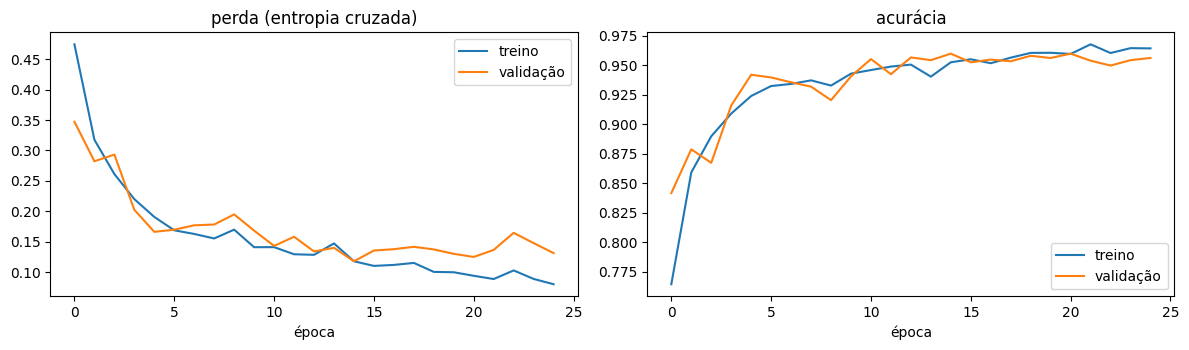

In [9]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 3.6))
for eixo, metrica, titulo in zip(eixos, ['loss', 'accuracy'], ['perda (entropia cruzada)', 'acurácia']):
    eixo.plot(hist_img.history[metrica], label='treino')
    eixo.plot(hist_img.history['val_' + metrica], label='validação')
    eixo.set(title=titulo, xlabel='época')
    eixo.legend()
plt.tight_layout()
plt.show()

## 6. Avaliação no teste

- **acurácia**: fração de batimentos classificados corretamente;
- **sensibilidade**: dos batimentos anormais, quantos o modelo detecta (o erro grave aqui é o falso negativo: infarto classificado como normal);
- **especificidade**: dos batimentos normais, quantos o modelo reconhece como normais;
- **AUC**: capacidade de ordenar anormais acima de normais em qualquer limiar (1,0 = perfeito; 0,5 = acaso).

              precision    recall  f1-score   support

      normal      0.949     0.891     0.919       607
     anormal      0.959     0.982     0.970      1576

    accuracy                          0.956      2183
   macro avg      0.954     0.936     0.945      2183
weighted avg      0.956     0.956     0.956      2183



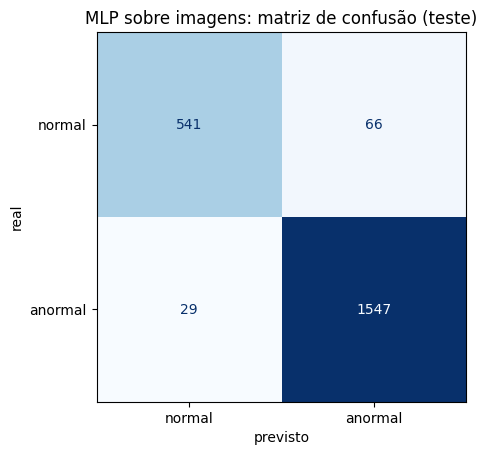

acurácia                   0.956
sensibilidade (anormal)    0.982
especificidade (normal)    0.891
AUC                        0.990
dtype: float64

In [10]:
def avaliar(modelo, X):
    p = modelo.predict(X[i_teste], verbose=0).ravel()
    previsto = (p >= 0.5).astype(int)
    return p, previsto, {'acurácia': accuracy_score(y[i_teste], previsto),
                         'sensibilidade (anormal)': recall_score(y[i_teste], previsto),
                         'especificidade (normal)': recall_score(y[i_teste], previsto, pos_label=0),
                         'AUC': roc_auc_score(y[i_teste], p)}


p_img, prev_img, metricas_img = avaliar(mlp_img, X_img)
print(classification_report(y[i_teste], prev_img, target_names=CLASSES, digits=3))
ConfusionMatrixDisplay.from_predictions(y[i_teste], prev_img, display_labels=CLASSES, cmap='Blues', colorbar=False)
plt.title('MLP sobre imagens: matriz de confusão (teste)')
plt.xlabel('previsto')
plt.ylabel('real')
plt.show()
pd.Series(metricas_img).round(3)

**Leitura:** 95,6% de acurácia no teste, bem acima dos 72,2% de quem responde sempre "anormal". A rede detecta 98,2% dos batimentos de infarto (sensibilidade) e reconhece 89,1% dos normais (especificidade); a AUC de 0,990 mostra que ela quase sempre dá probabilidade maior ao batimento anormal do que ao normal. Dos 2.183 batimentos de teste, 29 de infarto passaram como normais e 66 normais viraram alarme falso. O erro pende para o lado mais seguro em triagem, efeito dos pesos por classe. Como referência, o artigo de origem obteve 95,9% nesta mesma base com uma rede convolucional e transferência de aprendizado (com outra divisão dos dados).

## 7. Imagem × sinal bruto

A mesma rede, com a mesma divisão, treinada sobre as 187 amostras do sinal em vez dos 2.048 pixels da imagem:

In [11]:
mlp_sinal, hist_sinal = treinar(X_sinal)
_, _, metricas_sinal = avaliar(mlp_sinal, X_sinal)

pd.DataFrame({'MLP · imagem (2.048 pixels)': metricas_img,
              'MLP · sinal bruto (187 amostras)': metricas_sinal,
              'referência: responder sempre "anormal"': {'acurácia': y[i_teste].mean(),
                                                         'sensibilidade (anormal)': 1.0,
                                                         'especificidade (normal)': 0.0, 'AUC': 0.5}}).T.round(3)

,acurácia,sensibilidade (anormal),especificidade (normal),AUC
MLP · imagem (2.048 pixels),0.956,0.982,0.891,0.990
MLP · sinal bruto (187 amostras),0.949,0.951,0.942,0.986
"referência: responder sempre ""anormal""",0.722,1.000,0.000,0.500


A versão em imagem saiu um pouco melhor na acurácia (95,6% contra 94,9%) e na AUC (0,990 contra 0,986), com outro perfil de erro: mais sensível (98,2% contra 95,1%) e menos específica (89,1% contra 94,2%). Uma explicação provável é que o traço grosso e a redução por média de área suavizam o sinal. A diferença é pequena; o ponto principal é que transformar o sinal em imagem não destruiu a informação diagnóstica. O preço que a imagem cobra da MLP aparece no próximo teste.

## 8. A MLP enxerga posição, não forma

Teste simples: deslocar as imagens de teste alguns pixels para a direita. Para um cardiologista, o batimento continua o mesmo; para a MLP, cada pixel é uma entrada fixa.

In [12]:
# desloca as imagens de teste alguns pixels para a direita: o traçado é o mesmo, só muda de lugar
imagens_teste = X_img[i_teste].reshape(-1, ALTURA_MLP, LARGURA_MLP)
linhas = []
for dx in [0, 1, 2, 4, 8]:
    deslocadas = np.roll(imagens_teste, dx, axis=2)
    if dx:
        deslocadas[:, :, :dx] = imagens_teste[:, :, :1]  # o espaço aberto à esquerda repete a primeira coluna
    p = mlp_img.predict(deslocadas.reshape(len(i_teste), -1), verbose=0).ravel()
    linhas.append({'deslocamento (pixels)': dx,
                   'acurácia': accuracy_score(y[i_teste], (p >= 0.5).astype(int)),
                   'AUC': roc_auc_score(y[i_teste], p)})
pd.DataFrame(linhas).set_index('deslocamento (pixels)').round(3)

,acurácia,AUC
deslocamento (pixels),,
0,0.956,0.990
1,0.754,0.893
2,0.736,0.782
4,0.721,0.620
8,0.721,0.509


**Um pixel basta.** Deslocar a imagem 1 pixel (1/64 da largura, cerca de 23 ms de traçado) derruba a acurácia de 95,6% para 75,4% e a AUC de 0,990 para 0,893. Com 4 pixels a acurácia cai para 72,1%, o mesmo de responder sempre "anormal", e com 8 pixels a AUC chega a 0,509, nível de acaso.

A MLP não aprendeu a *forma* do batimento: aprendeu em que pixel cada parte do traçado costuma estar. Isso só funciona aqui porque todas as imagens foram geradas exatamente alinhadas, com todo batimento começando no pico R, na primeira coluna. Uma foto real de ECG nunca vem assim. Redes convolucionais (CNN), tema da Fase 4 do CardioIA, resolvem o problema com filtros que deslizam pela imagem e reconhecem o mesmo padrão em qualquer posição.

## 9. Onde a rede erra

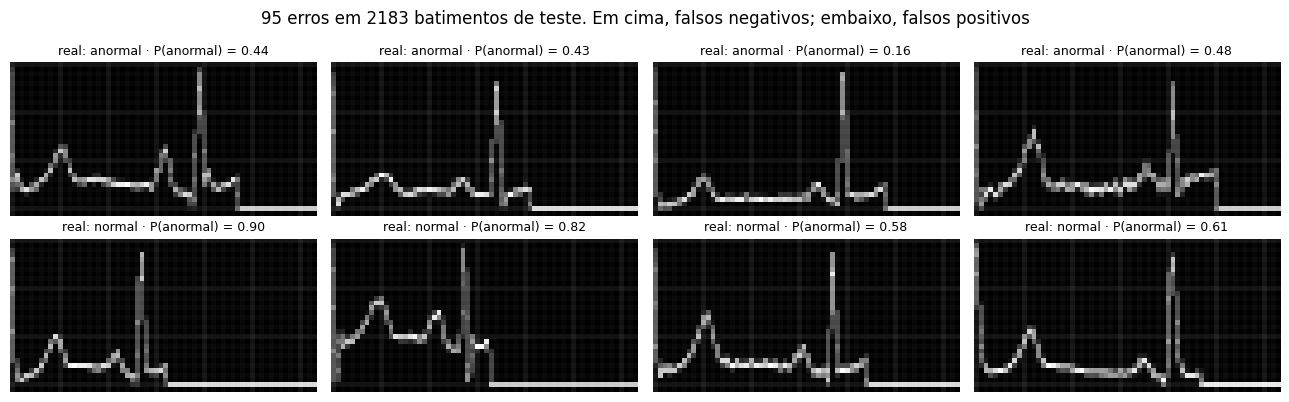

40% dos erros têm P(anormal) entre 0,3 e 0,7 (casos de fronteira)


In [13]:
erro = prev_img != y[i_teste]
fig, eixos = plt.subplots(2, 4, figsize=(13, 4.2))
for eixos_linha, real in zip(eixos, [1, 0]):
    for eixo, pos in zip(eixos_linha, np.flatnonzero(erro & (y[i_teste] == real))[:4]):
        eixo.imshow(X_img[i_teste[pos]].reshape(ALTURA_MLP, LARGURA_MLP), cmap='gray')
        eixo.set_title(f'real: {CLASSES[real]} · P(anormal) = {p_img[pos]:.2f}', fontsize=9)
        eixo.axis('off')
plt.suptitle(f'{erro.sum()} erros em {len(i_teste)} batimentos de teste. '
             'Em cima, falsos negativos; embaixo, falsos positivos')
plt.tight_layout()
plt.show()

fronteira = np.mean((p_img[erro] > 0.3) & (p_img[erro] < 0.7))
print(f'{fronteira:.0%} dos erros têm P(anormal) entre 0,3 e 0,7 (casos de fronteira)')

Só 40% dos 95 erros (4,4% do teste) são casos de fronteira, com P(anormal) entre 0,3 e 0,7. Os outros 60% são erros **com convicção**, como os falsos positivos acima com P = 0,90 e 0,82, e são os mais perigosos: uma probabilidade alta passa uma segurança que o modelo não tem. Os falsos negativos mostrados têm a forma de um batimento normal; num único batimento de uma única derivação, as alterações do infarto podem simplesmente não aparecer.

## 10. Limitações e responsabilidade

- **Vazamento entre pacientes, a limitação mais séria.** O CSV não informa a qual pessoa pertence cada batimento, e cada exame gera dezenas de batimentos. Com divisão aleatória, batimentos da mesma pessoa caem no treino e no teste, e a rede pode reconhecer *a pessoa* em vez da *doença*. A literatura recomenda separar por paciente (paradigma interpacientes; de Chazal et al., 2004); com pacientes novos, o desempenho tende a ser menor que o medido aqui.
- **População.** A PTB tem 290 pessoas de um único centro alemão: 209 homens (72%) e 81 mulheres. É o mesmo desequilíbrio de sexo apontado na Fase 1, cuja base tem 61% de homens. Sem o sexo de cada batimento, não dá para medir o desempenho por subgrupo, medida que seria obrigatória antes de qualquer uso.
- **Imagens limpas e alinhadas.** As imagens foram desenhadas a partir do sinal, sem inclinação, sombra, ruído ou variação de escala. O teste de deslocamento mostra que a MLP não tolera nem 1 pixel; uma foto real exigiria aumento de dados e, de preferência, uma CNN.
- **Um batimento, uma derivação.** O diagnóstico de infarto usa as 12 derivações, a evolução do traçado, exames de sangue e a história do paciente.
- **Uso.** Material educacional. Um classificador assim só faria sentido como apoio à triagem, com o médico no circuito e validação clínica prévia.

## Conclusão

A MLP atingiu 95,6% de acurácia e AUC de 0,990 classificando imagens de batimentos como normais ou de infarto, perto dos 95,9% que o artigo de origem obteve com uma rede convolucional. O número é bom, mas o teste de deslocamento mostra o limite da arquitetura: a rede decorou posições de pixels em vez de aprender a forma do batimento. Para imagens de ECG do mundo real, o próximo passo é a visão computacional com CNN, tema da Fase 4.

## Referências

- Bousseljot R, Kreiseler D, Schnabel A. Nutzung der EKG-Signaldatenbank CARDIODAT der PTB über das Internet. *Biomedizinische Technik*. 1995;40(S1):317.
- Goldberger AL et al. PhysioBank, PhysioToolkit, and PhysioNet. *Circulation*. 2000;101(23):e215–e220.
- Kachuee M, Fazeli S, Sarrafzadeh M. ECG Heartbeat Classification: A Deep Transferable Representation. *IEEE ICHI*, 2018. arXiv:1805.00794.
- de Chazal P, O'Dwyer M, Reilly RB. Automatic classification of heartbeats using ECG morphology and heartbeat interval features. *IEEE Trans Biomed Eng*. 2004;51(7):1196–1206.
- Dataset: https://www.kaggle.com/datasets/shayanfazeli/heartbeat · PTB Diagnostic ECG Database: https://physionet.org/content/ptbdb/1.0.0/